The following is an analysis based on data from a dataset dubbed "Social Media Impact on Teen Mental Health", from the website 'Kaggle' which was used by the author for their own AI training. Although presumably from a real source, the author of the data does not give credit to the source which the data was taken from, nor what methods were used in collecting this data, meaning all conclusions based on this data should at best be taken as hypothetical.

In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from IPython.display import display, clear_output



def read_csv(filename: str):
    csv_path = Path("data") / filename
    df = pd.read_csv(csv_path)
    return df

def group_by_gender(data :pd.DataFrame): #returns groupby object
    out = data.groupby("gender")
    return out

df = read_csv("Teen_Mental_Health_Dataset.csv")

print(f"The shape of the data is as follows: {df.shape}, meaning {df.shape[0]} entries, and {df.shape[1]} fields.\n")
print("The following fields of the data contain various formats, as can be seen with the following:")
print(df.info())
print("\nAs the dataset used is already cleaned there are no null entries, as can be seen following:")
print(df.isnull().sum())
print("\nFurther summary of the data, such as mean values and standard deviations for each of the fields, can be seen in following, although further analysis will be saved for later:")
print(df.describe())


The shape of the data is as follows: (1200, 13), meaning 1200 entries, and 13 fields.

The following fields of the data contain various formats, as can be seen with the following:
<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   str    
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   str    
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   str    
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addi

(Since the dataset is already cleaned there is no need to clean it again, but if not, we could simply use the existing pandas function "df.dropna()" to drop all entries which are missing any data, and continue any future operations on the output given)

Since we do have quite a robust dataset (the admission of how it was collected aside), it can also be utilized to answer a few questions. The original author from where the data was published utilized it to train an AI model to make predictions.

We, of course, do not have a trained AI at hand, so we will limit our analysis to what the dataset can answer through traditional data analysis methods.

Although there are quite a few things which the dataset lends itself to examine, we will limit it to a pretty straight forward hypothesis, that a greater amount of social media usage has a negative impact on teens, measured here through factors such as academic performance and anxiety, we will also examine whether aspects such as gender could be a confluencing factor.

Lets start off with a simple visualization of social media usage by gender:

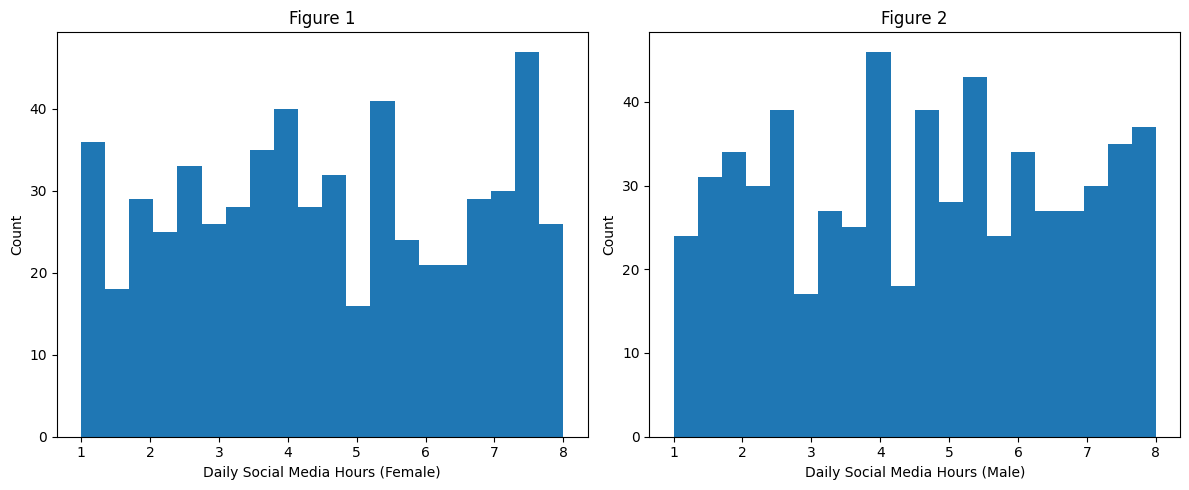

In [ ]:
#if problems occur with notebook refusing to render copy this %matplotlib inline and run it first

def group_by_gender(data :pd.DataFrame): #returns groupby object
    out = data.groupby("gender")
    return out

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

grouped = group_by_gender(df)

#Histogram (female)
axes[0].hist(grouped.get_group("female")["daily_social_media_hours"], bins=20)
axes[0].set_title("Figure 1")
axes[0].set_xlabel("Daily Social Media Hours (Female)")
axes[0].set_ylabel("Count")

#Histogram (male)
axes[1].hist(grouped.get_group("male")["daily_social_media_hours"], bins=20)
axes[1].set_title("Figure 2")
axes[1].set_xlabel("Daily Social Media Hours (Male)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

We do see quite some difference, here lets show that again with the values next to one another, while also not grouping the floating point answers in a histogram:

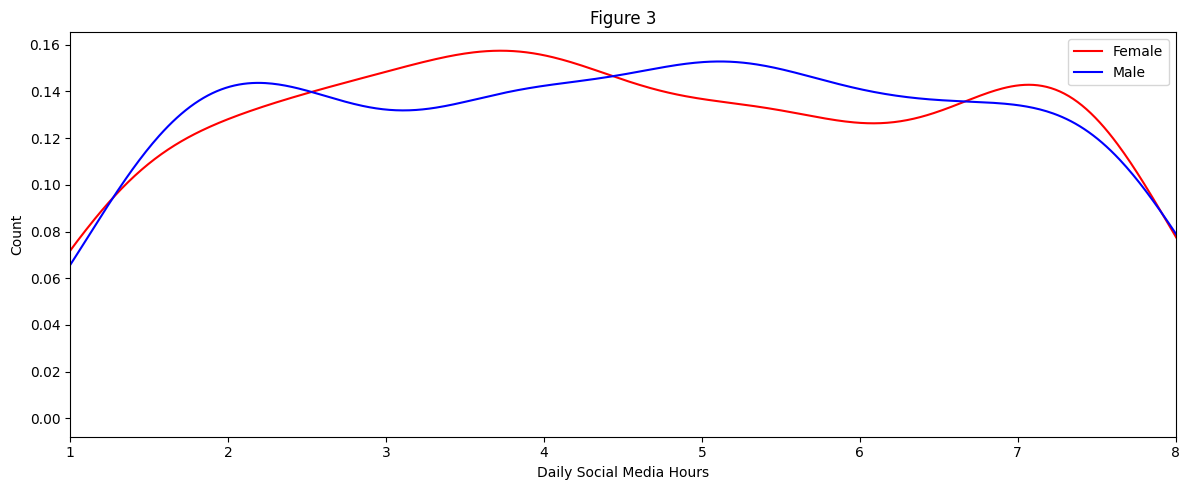

In [178]:
fig, ax = plt.subplots(figsize=(12, 5))

grouped = group_by_gender(df)

femaleVals = grouped.get_group("female")["daily_social_media_hours"]
maleVals = grouped.get_group("male")["daily_social_media_hours"]

femaleVals.plot(kind="kde", ax=ax, label="Female", color="red")
maleVals.plot(kind="kde", ax=ax, label="Male", color="blue")

ax.set_title("Figure 3")
ax.set_xlabel("Daily Social Media Hours")
ax.set_ylabel("Count")
ax.legend()

ax.set_xlim(1, 8) #Limiting it to the entries we actuallyh have data for, the teens not being able to report a value below 1, or above 8 is a limitation of the study/dataset, not of the visualization

plt.tight_layout()
plt.show()

Notably, we do see some differences in behaviour, with more women answering that they use social media around 1 hour, and more men answering that the use it for 8. (The minimum/maximum available values respectively).
We can also get their respective standard deviations through the following:

In [188]:
print("Female std:", femaleVals.std())
print("Male std:", maleVals.std(), "\n")


print("Female mean:", femaleVals.mean())
print("Male mean:", maleVals.mean())
d = (femaleVals.mean() - maleVals.mean()) / np.sqrt((femaleVals.var() + maleVals.var()) / 2)
print("Difference", d)


Female std: 2.0363903672102137
Male std: 2.0245181167483386 

Female mean: 4.512991452991454
Male mean: 4.559186991869918
Difference -0.022751234923344108


In this we see that although we get some differences in actual values, the mean of both values are essentially the same. We also calculate the Cohen difference between the means, showing no real difference.

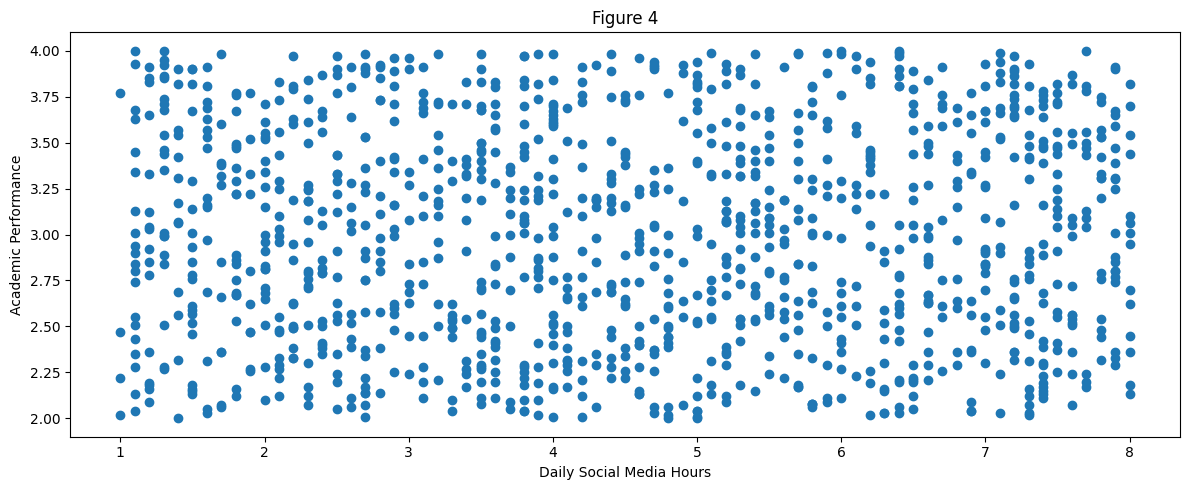

In [189]:
fig1, ax1 = plt.subplots(figsize=(12, 5))

#Scatter plot
ax1.scatter(df["daily_social_media_hours"], df["academic_performance"])
ax1.set_title("Figure 4")
ax1.set_xlabel("Daily Social Media Hours")
ax1.set_ylabel("Academic Performance")

plt.tight_layout()
plt.show()


Looking at the data in figure 1, we don't seem to see any corrolation between the 2 factors, with a seemingly random pattern appearing. Indeed looking at the data using the following code, we don't seem to find any notable corrolation between the 2 factors. With a Pearson r correlation coefficient below what is considered statistically relevant.

In [190]:
print(df["daily_social_media_hours"].corr(df["academic_performance"]))

0.013178979116841249


We can also repeat this testing methodology for anxiety, using Seaborn for the visualization instead

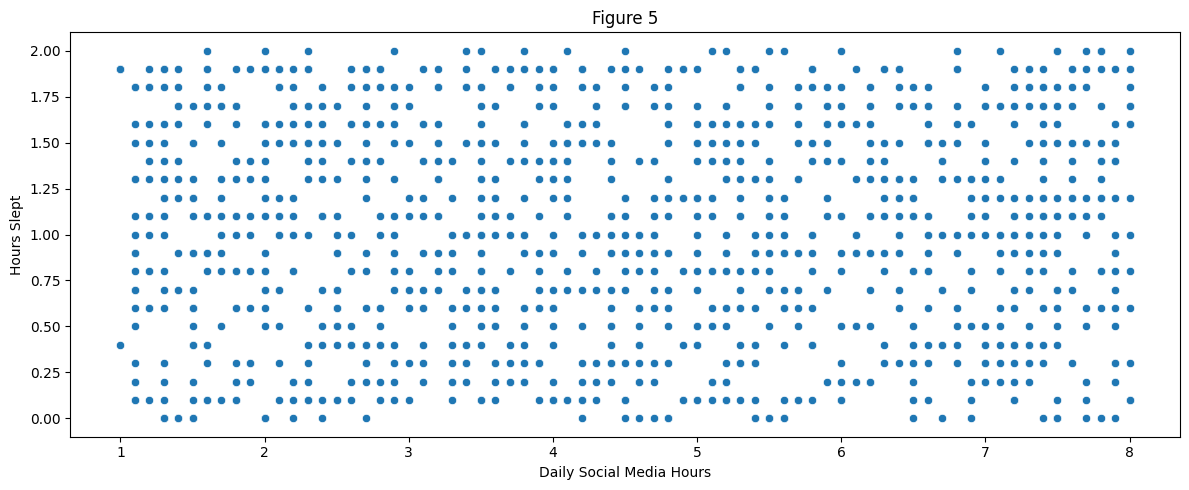

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

fig1, ax2 = plt.subplots(figsize=(12, 5))

sns.scatterplot(
    data=df,
    x="daily_social_media_hours",
    y="sleep_hours",
    ax=ax1
)

ax2.set_title("Figure 5")
ax2.set_xlabel("Daily Social Media Hours")
ax2.set_ylabel("Hours Slept")

plt.tight_layout()
plt.show()


In [195]:
print(df["daily_social_media_hours"].corr(df["sleep_hours"]))

-0.009472174451730868


The results, again, prove to be essentially, random. Both not showing any correlation, but, perhaps more importantly at this point, also not showing any trends.

Although the data showed no correlation, no trends, and the genders showed to be essentially the same, data wise, when it came to social media usage, we can also do some testing for each gender:

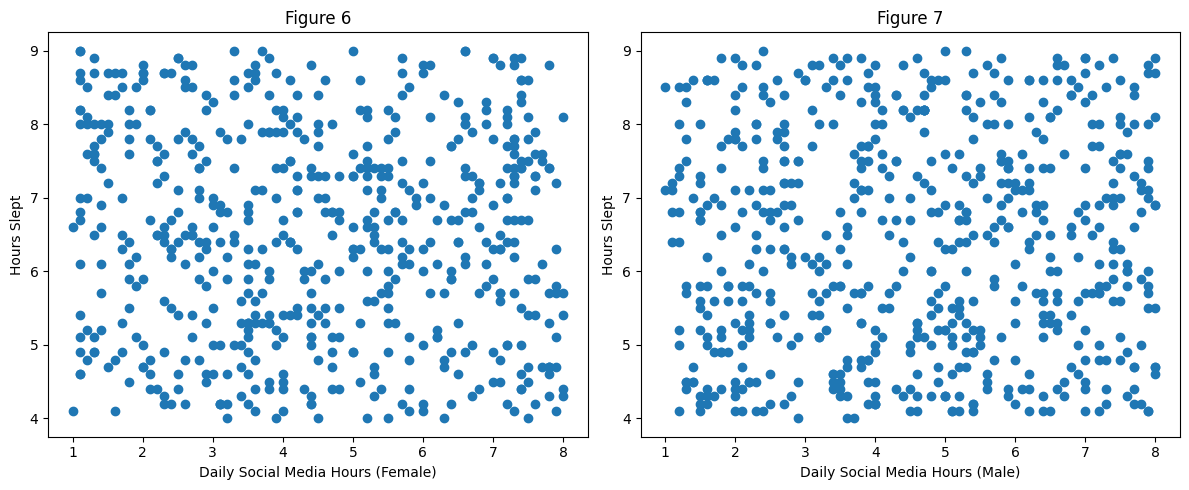

In [200]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

grouped = group_by_gender(df)

axes[0].scatter(grouped.get_group("female")["daily_social_media_hours"], grouped.get_group("female")["sleep_hours"])
axes[0].set_title("Figure 6")
axes[0].set_xlabel("Daily Social Media Hours (Female)")
axes[0].set_ylabel("Hours Slept")

axes[1].scatter(grouped.get_group("male")["daily_social_media_hours"], grouped.get_group("male")["sleep_hours"])
axes[1].set_title("Figure 7")
axes[1].set_xlabel("Daily Social Media Hours (Male)")
axes[1].set_ylabel("Hours Slept")

plt.tight_layout()
plt.show()

In [201]:
print("Male correlation: ", grouped.get_group("female")["daily_social_media_hours"].corr(grouped.get_group("female")["academic_performance"]))
print("Male correlation: ", grouped.get_group("male")["daily_social_media_hours"].corr(grouped.get_group("male")["academic_performance"]))

Male correlation:  0.01962743001585529
Male correlation:  0.00716317629425924


Again, neither meet the threshold for any form of correlation

To conclude, it can be fairly certain, that the data provided here, was not so much 'cleaned' as it was generated, or randomized. While this isn't the most fun thing to mid-project, it does not change the conclusion much from an unknown dataset, which unknown methods of data collection. Which is that any conclusion drawn upon such a dataset should be taken with a giant pinch of salt.

Regardless, if we are to ignore the problems surrounding the data for a moment, the conclusions we could draw would be as follows; Specifically that no significant correlations could be drawn between social media usage and the factors we studied, namely Academic performance, and Sleep. This did not change while factoring in gender.
While normally in social studies we would at this point be highlighting that further studies would be encouraged where we saw interesting trendlines, this isn't such a case, as we saw no distinct or interesting patterns to highlight, although perhaps the high uniformity would be considered interesting in itself, if this were to be treated as real data.